# C2 (UNSW-NB15): Sức mạnh Biểu diễn của Quantum Kernel (ZZFeatureMap)

## 1. Bối cảnh Khoa học (Generalization Test)

Notebook này **kiểm chứng giả thuyết khả năng biểu diễn của Quantum Kernel trên một dataset hoàn toàn mới** — UNSW-NB15. Sau khi C2 trên NSL-KDD đã xác nhận:

> *ZZFeatureMap khám phá Hilbert space gần như đồng nhất với phân phối Haar-random, đồng thời tạo ra entanglement có ý nghĩa thống kê giữa các nhóm Normal vs Attack.*

câu hỏi tiếp theo là: **Liệu kết luận này có giữ vững khi pipeline được port qua một phân phối mạng khác?** Nếu đúng, ta có bằng chứng cho tính phổ quát của lợi thế lượng tử trong ngữ cảnh IDS — yếu tố cực kỳ quan trọng cho bài báo IEEE.

## 2. Đầu vào và Ràng buộc Phần cứng

- **Dữ liệu:** `UNSW_Train_PCA4D.parquet` đã hoàn tất Phase 1-3:
  - OHE 186 → SelectKBest K=35 (elbow) → PCA n=4 (86.96% variance) → MinMax(0, π)
  - Spearman residual giữa các PC ≈ 0.405 (PC3-PC4) — đây chính là **substrate** mà ZZ-entanglement được kỳ vọng khai thác
- **Phần cứng giả lập:** 4 qubits, ZZFeatureMap reps=2, full entanglement
- **Ngân sách tính toán:** Vì độ phức tạp O(N²) cho ma trận kernel và O(N) cho entropy/expressibility, ta lấy mẫu **N=500** (tỉ lệ Normal/Attack giữ nguyên) từ tập train. Quy mô này đủ để các thống kê (KL, Mann-Whitney, eigenspectrum) hội tụ nhưng vẫn hoàn thành dưới 5 phút trên CPU.

## 3. Các Thí nghiệm Trong Notebook

| § | Phép đo | Mục tiêu khoa học |
|---|---------|-------------------|
| 5 | Fidelity vs Haar Beta(1, 15) — KL divergence | H1: ZZFeatureMap có expressibility cao trên UNSW? |
| 6 | Eigenspectrum của ma trận kernel ZZ | Đo độ phong phú không gian feature (effective rank) |
| 7 | Von Neumann Entropy bipartition {0,1}\|{2,3} | H2: Entanglement phân biệt Normal vs Attack? |

Tất cả output ghi vào `../reports_unsw/` (KHÔNG ghi đè plots NSL-KDD trong `../reports/`).


In [ ]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

warnings.filterwarnings('ignore')

# Qiskit (2.3.0): API chuc nang lowercase
from qiskit.circuit.library import zz_feature_map, z_feature_map
from qiskit.quantum_info import Statevector, partial_trace, entropy as von_neumann_entropy

# Khoa hoc + thong ke
from scipy.stats import beta as beta_dist, mannwhitneyu, gaussian_kde
from sklearn.model_selection import train_test_split

# ── Hang so toan cuc ────────────────────────────────────────────────
N_QUBITS         = 4               # Rang buoc phan cung NISQ (4 qubit)
HILBERT_DIM      = 2 ** N_QUBITS   # = 16
N_HAAR           = HILBERT_DIM - 1 # Tham so b cua Beta(1, 2^n - 1)
N_SUBSAMPLE      = 500             # Stratified subsample (tranh O(N^2) bottleneck)
N_EXPR_PAIRS     = 2000            # So cap (x_a, x_b) cho phan tich expressibility
ZZ_REPS_TARGET   = 2               # Cau hinh ZZ chinh dung trong toan project
ZZ_ENT_TARGET    = "full"         # Full entanglement = tat ca 6 cap qubit
RANDOM_STATE     = 42

# Duong dan I/O — KHONG dung lai dirs cua NSL-KDD
DATA_PATH        = "../data/unsw_nb15/processed_data/UNSW_Train_PCA4D.parquet"
REPORTS_DIR      = "../reports_unsw"
RESULTS_JSON     = os.path.join(REPORTS_DIR, "c2_unsw_results.json")
os.makedirs(REPORTS_DIR, exist_ok=True)

LABEL_COLS       = ["label_binary", "label_multiclass", "attack_category"]

print("Import hoan tat (Qiskit 2.3.0).")
print(f"Cau hinh: N_SUBSAMPLE={N_SUBSAMPLE}, reps={ZZ_REPS_TARGET}, "
      f"entanglement={ZZ_ENT_TARGET!r}, N_EXPR_PAIRS={N_EXPR_PAIRS}")
print(f"Output dir: {REPORTS_DIR}")


Import hoan tat (Qiskit 2.3.0).
Cau hinh: N_SUBSAMPLE=500, reps=2, entanglement='full', N_EXPR_PAIRS=2000
Output dir: ../reports_unsw


## 4. Các Hàm Tiện Ích

### 4.1 Tại sao dùng Statevector trực tiếp thay vì FidelityQuantumKernel?

`FidelityQuantumKernel` (Qiskit ML) gọi sampler primitive bên trong, tạo overhead lớn cho mỗi cặp (x_a, x_b). Với N=500 ta cần ≈125,000 fidelity → loop FidelityQuantumKernel mất **1-3 giờ**.

**Tối ưu hóa:** vì 4 qubit chỉ có $2^4 = 16$ chiều, ta tính trực tiếp các statevector $|\psi(x_i)\rangle \in \mathbb{C}^{16}$ trước (chỉ 500 lần evaluate circuit), sau đó:
$$K_{ij} = |\langle \psi(x_i) | \psi(x_j) \rangle|^2$$
chính là phép nhân ma trận `(N×16) @ (16×N) = (N×N)` — chỉ vài mili-giây. Tổng thời gian tính kernel matrix: **<10 giây**.

### 4.2 Lý thuyết KL Divergence với Haar Random

Theo Sim et al. (2019), expressibility của một parameterized quantum circuit (PQC) được đánh giá bằng độ gần của phân phối fidelity $P_{\text{circuit}}(F)$ với phân phối Haar-random:
$$P_{\text{Haar}}(F) = (2^n - 1)(1 - F)^{2^n - 2} = \text{Beta}(F; 1, 2^n - 1)$$

Với 4 qubit: $P_{\text{Haar}} = \text{Beta}(1, 15)$. KL divergence càng nhỏ → mạch càng khám phá Hilbert space đồng đều như Haar → expressibility càng cao.

In [ ]:
def stratified_subsample(X, y, sample_size, random_state=RANDOM_STATE):
    """Lay mau phan tang gi nguyen ti le lop binary."""
    if sample_size >= len(y):
        raise ValueError(f"sample_size={sample_size} phai < len(y)={len(y)}")
    discard_fraction = 1.0 - sample_size / len(y)
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        test_size=discard_fraction,
        stratify=y,
        random_state=random_state,
    )
    return X_sub, y_sub


def build_statevectors(X, feature_map_fn, **fm_kwargs):
    """Tinh tat ca statevector |psi(x_i)> cho moi mau du lieu.

    Tra ve mang phuc kich thuoc (N, 2^n_qubits). Tai su dung circuit base
    de tranh chi phi build lai moi vong lap.
    """
    base_circ = feature_map_fn(N_QUBITS, **fm_kwargs)
    params    = list(base_circ.parameters)
    n_dim     = HILBERT_DIM
    states    = np.zeros((len(X), n_dim), dtype=np.complex128)
    for i, x in enumerate(X):
        bound = base_circ.assign_parameters(dict(zip(params, x)))
        states[i] = np.asarray(Statevector(bound).data)
    return states


def fidelity_kernel_from_states(states):
    """Tinh ma tran kernel K_ij = |<psi_i|psi_j>|^2 tu mang statevector.

    Toan bo tinh toan trong O(N^2 * d) = O(N^2 * 16) — rat nhanh cho 4 qubit.
    """
    overlap = states.conj() @ states.T   # (N, N) complex
    return np.abs(overlap) ** 2


def pair_fidelities(X_a, X_b, feature_map_fn, **fm_kwargs):
    """Tinh fidelity tren cac cap (x_a[i], x_b[i]) — KHONG phai cross product.

    Dung cho phan tich expressibility (N_EXPR_PAIRS cap doc lap).
    """
    sv_a = build_statevectors(X_a, feature_map_fn, **fm_kwargs)
    sv_b = build_statevectors(X_b, feature_map_fn, **fm_kwargs)
    inner = np.einsum('ij,ij->i', sv_a.conj(), sv_b)
    return np.abs(inner) ** 2


def kl_divergence_from_haar(fidelities, n_qubits=N_QUBITS, n_bins=50):
    """D_KL(P_circuit || P_Haar = Beta(1, 2^n - 1)).

    KL thap = phan phoi gan Haar-random = expressibility cao.
    """
    N_haar    = 2 ** n_qubits - 1
    bins      = np.linspace(0, 1, n_bins + 1)
    counts, _ = np.histogram(fidelities, bins=bins, density=False)
    total     = counts.sum()
    if total == 0:
        return float('inf')
    p_obs     = counts / total

    bin_mid   = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]
    p_haar    = beta_dist.pdf(bin_mid, a=1, b=N_haar) * bin_width
    p_haar    = p_haar / p_haar.sum()

    eps       = 1e-12
    kl        = np.sum(np.where(p_obs > eps,
                                p_obs * np.log((p_obs + eps) / (p_haar + eps)),
                                0.0))
    return float(kl)


def compute_entanglement_entropy(x, reps=ZZ_REPS_TARGET, entanglement=ZZ_ENT_TARGET):
    """Von Neumann entropy bipartition {0,1} | {2,3} cua trang thai ZZFeatureMap.

    Tra ve S in [0, 2] bit (toi da 2 bit cho he hai sub-system 2 qubit).
    """
    circ  = zz_feature_map(N_QUBITS, reps=reps, entanglement=entanglement)
    bound = circ.assign_parameters(dict(zip(circ.parameters, x)))
    sv    = Statevector(bound)
    rho_A = partial_trace(sv, qargs=(2, 3))   # trace out qubit {2, 3}
    return float(von_neumann_entropy(rho_A, base=2))


def effective_rank(K):
    """Effective rank = (sum sigma_i)^2 / (sum sigma_i^2). Tu 1 toi N."""
    sigmas = np.linalg.svd(K, compute_uv=False)
    sigmas = sigmas[sigmas > 1e-12]
    if len(sigmas) == 0:
        return 1.0
    return float(sigmas.sum() ** 2 / (sigmas ** 2).sum())


print("Cac ham tien ich da duoc dinh nghia.")


Cac ham tien ich da duoc dinh nghia.


## 5. Tải dữ liệu UNSW-NB15 đã chuẩn hóa và Stratified Subsample

Pipeline đầu vào (đã hoàn tất Phases 1-3):
1. **Phase 1:** OHE → 186 features
2. **Phase 2:** SelectKBest(F-test) → K=35 features (elbow tại 0.83 F1-points dưới max)
3. **Phase 3:** PCA(n=4, var=86.96%) → MinMaxScaler(feature_range=(0, π))

**Quan trọng:** `UNSW_Train_PCA4D.parquet` đã chứa 4 PC ở [0, π] → có thể đưa thẳng vào ZZFeatureMap mà KHÔNG cần fit/transform thêm. Đây là điểm khác biệt với reference NSL-KDD (load nhiều joblib transformer).

In [3]:
print(f"Dang tai {DATA_PATH}...")
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Cot: {list(df.columns)}")

# Tach feature va nhan
feature_cols = [c for c in df.columns if c not in LABEL_COLS]
assert len(feature_cols) == N_QUBITS, \
    f"Mong doi {N_QUBITS} PC, nhan duoc {len(feature_cols)}: {feature_cols}"

X_full = df[feature_cols].values.astype(np.float64)
y_full = df["label_binary"].values.astype(int)

print(f"\nFeature columns: {feature_cols}")
print(f"X_full shape: {X_full.shape},  pham vi=[{X_full.min():.4f}, {X_full.max():.4f}]")
print(f"y_full balance: Normal={int((y_full==0).sum()):,} ({(y_full==0).mean():.1%}) | "
      f"Attack={int((y_full==1).sum()):,} ({(y_full==1).mean():.1%})")
assert X_full.min() >= 0.0 and X_full.max() <= np.pi + 1e-6, \
    "X phai nam trong [0, pi] (kiem tra Phase 3)"

# Stratified subsample N=500 (giu nguyen ti le binary)
X_sub, y_sub = stratified_subsample(X_full, y_full, N_SUBSAMPLE, RANDOM_STATE)

# Sap xep theo nhan de heatmap/eigenspectrum block-structured (Normal truoc, Attack sau)
sort_idx    = np.argsort(y_sub)
X_sub       = X_sub[sort_idx]
y_sub       = y_sub[sort_idx]
n_normal    = int((y_sub == 0).sum())
n_attack    = int((y_sub == 1).sum())

print(f"\nStratified subsample N={N_SUBSAMPLE} (seed={RANDOM_STATE}):")
print(f"  Normal (lop 0): {n_normal} ({n_normal/N_SUBSAMPLE:.1%})")
print(f"  Attack (lop 1): {n_attack} ({n_attack/N_SUBSAMPLE:.1%})")
print(f"  Pham vi sau subsample: [{X_sub.min():.4f}, {X_sub.max():.4f}]")


Dang tai ../data/unsw_nb15/processed_data/UNSW_Train_PCA4D.parquet...
Shape: (175341, 7)
Cot: ['PC1', 'PC2', 'PC3', 'PC4', 'label_binary', 'label_multiclass', 'attack_category']

Feature columns: ['PC1', 'PC2', 'PC3', 'PC4']
X_full shape: (175341, 4),  pham vi=[0.0000, 3.1416]
y_full balance: Normal=56,000 (31.9%) | Attack=119,341 (68.1%)

Stratified subsample N=500 (seed=42):
  Normal (lop 0): 160 (32.0%)
  Attack (lop 1): 340 (68.0%)
  Pham vi sau subsample: [0.0170, 3.1416]


## 6. Expressibility — KL Divergence vs Haar (Sim et al., 2019)

Quy trình:
1. Lấy mẫu $N_{\text{pairs}} = 2000$ cặp $(x_a, x_b)$ ngẫu nhiên đồng đều trong $[0, \pi]^4$
2. Đối với mỗi cấu hình circuit (ZZ reps=1,2,3 và Z baseline), tính fidelity $|\langle \psi(x_a) | \psi(x_b) \rangle|^2$
3. Đo histogram và tính $D_{KL}(P_{\text{circuit}} \| P_{\text{Haar}})$ với 50 bins

**Kỳ vọng (H1 — đơn điệu theo reps):** $D_{KL}(\text{reps}=1) > D_{KL}(\text{reps}=2) > D_{KL}(\text{reps}=3)$. Mỗi reps thêm CNOT-P-CNOT layer → trải state ra rộng hơn → gần Haar hơn.

**ZFeatureMap baseline:** Không có entanglement → state luôn là tensor product → fidelity tập trung quanh tích đơn lẻ → $D_{KL}$ rất cao (xa Haar). Đây là evidence trực tiếp rằng entanglement là cơ chế chính tạo expressibility.

In [4]:
rng = np.random.RandomState(RANDOM_STATE)

# Cau hinh ablation: ZZ reps = [1, 2, 3] + Z baseline
configs = [
    {"name": "ZZ_reps1",   "fn": zz_feature_map, "kwargs": {"reps": 1, "entanglement": "full"}, "color": "#d62728"},
    {"name": "ZZ_reps2",   "fn": zz_feature_map, "kwargs": {"reps": 2, "entanglement": "full"}, "color": "#ff7f0e"},
    {"name": "ZZ_reps3",   "fn": zz_feature_map, "kwargs": {"reps": 3, "entanglement": "full"}, "color": "#1f77b4"},
    {"name": "Z_reps2",    "fn": z_feature_map,  "kwargs": {"reps": 2},                          "color": "#7f7f7f"},
]

# Tao moi mot tap pair de fair comparison giua cac cau hinh
X_a = rng.uniform(0, np.pi, size=(N_EXPR_PAIRS, N_QUBITS))
X_b = rng.uniform(0, np.pi, size=(N_EXPR_PAIRS, N_QUBITS))

kl_values      = {}
fidelities_all = {}

print(f"Tinh fidelity tren {N_EXPR_PAIRS} cap [0, pi]^4 cho moi cau hinh...\n")
for cfg in configs:
    t0 = time.time()
    fids = pair_fidelities(X_a, X_b, cfg["fn"], **cfg["kwargs"])
    kl   = kl_divergence_from_haar(fids, n_qubits=N_QUBITS, n_bins=50)
    fidelities_all[cfg["name"]] = fids
    kl_values[cfg["name"]]      = kl
    dt = time.time() - t0
    print(f"  {cfg['name']:>10s}: D_KL={kl:.4f}  mean(F)={fids.mean():.4f}  "
          f"std(F)={fids.std():.4f}  ({dt:.1f}s)")

# Kiem tra don dieu (H1)
zz_kl = [kl_values[f"ZZ_reps{r}"] for r in [1, 2, 3]]
h1_strict   = zz_kl[0] >= zz_kl[1] >= zz_kl[2]
h1_partial  = zz_kl[1] <= zz_kl[0]   # reps=2 it nhat tot hon reps=1
print(f"\nKiem tra H1 (D_KL giam don dieu theo reps):")
print(f"  ZZ reps 1->2->3: {zz_kl[0]:.4f} -> {zz_kl[1]:.4f} -> {zz_kl[2]:.4f}")
print(f"  Don dieu nghiem ngat: {h1_strict}")
print(f"  reps=2 vs reps=1:   {'CAI THIEN' if h1_partial else 'KHONG CAI THIEN'}")

# So sanh ZZ vs Z (nen co gap lon)
gap_zz_vs_z = kl_values["Z_reps2"] - kl_values["ZZ_reps2"]
print(f"\nKhoang cach Z baseline vs ZZ chinh: D_KL_Z2 - D_KL_ZZ2 = {gap_zz_vs_z:.4f}")
print(f"  -> ZFeatureMap kem expressibility hon ZZ-{ZZ_REPS_TARGET} {gap_zz_vs_z:.2f} units D_KL")


Tinh fidelity tren 2000 cap [0, pi]^4 cho moi cau hinh...



    ZZ_reps1: D_KL=0.0230  mean(F)=0.0700  std(F)=0.0710  (2.5s)


    ZZ_reps2: D_KL=0.0221  mean(F)=0.0729  std(F)=0.0697  (4.5s)


    ZZ_reps3: D_KL=0.0355  mean(F)=0.0769  std(F)=0.0715  (6.3s)


     Z_reps2: D_KL=0.9183  mean(F)=0.1474  std(F)=0.1684  (1.6s)

Kiem tra H1 (D_KL giam don dieu theo reps):
  ZZ reps 1->2->3: 0.0230 -> 0.0221 -> 0.0355
  Don dieu nghiem ngat: False
  reps=2 vs reps=1:   CAI THIEN

Khoang cach Z baseline vs ZZ chinh: D_KL_Z2 - D_KL_ZZ2 = 0.8962
  -> ZFeatureMap kem expressibility hon ZZ-2 0.90 units D_KL


Da luu: ../reports_unsw\unsw_expressibility_kl.png


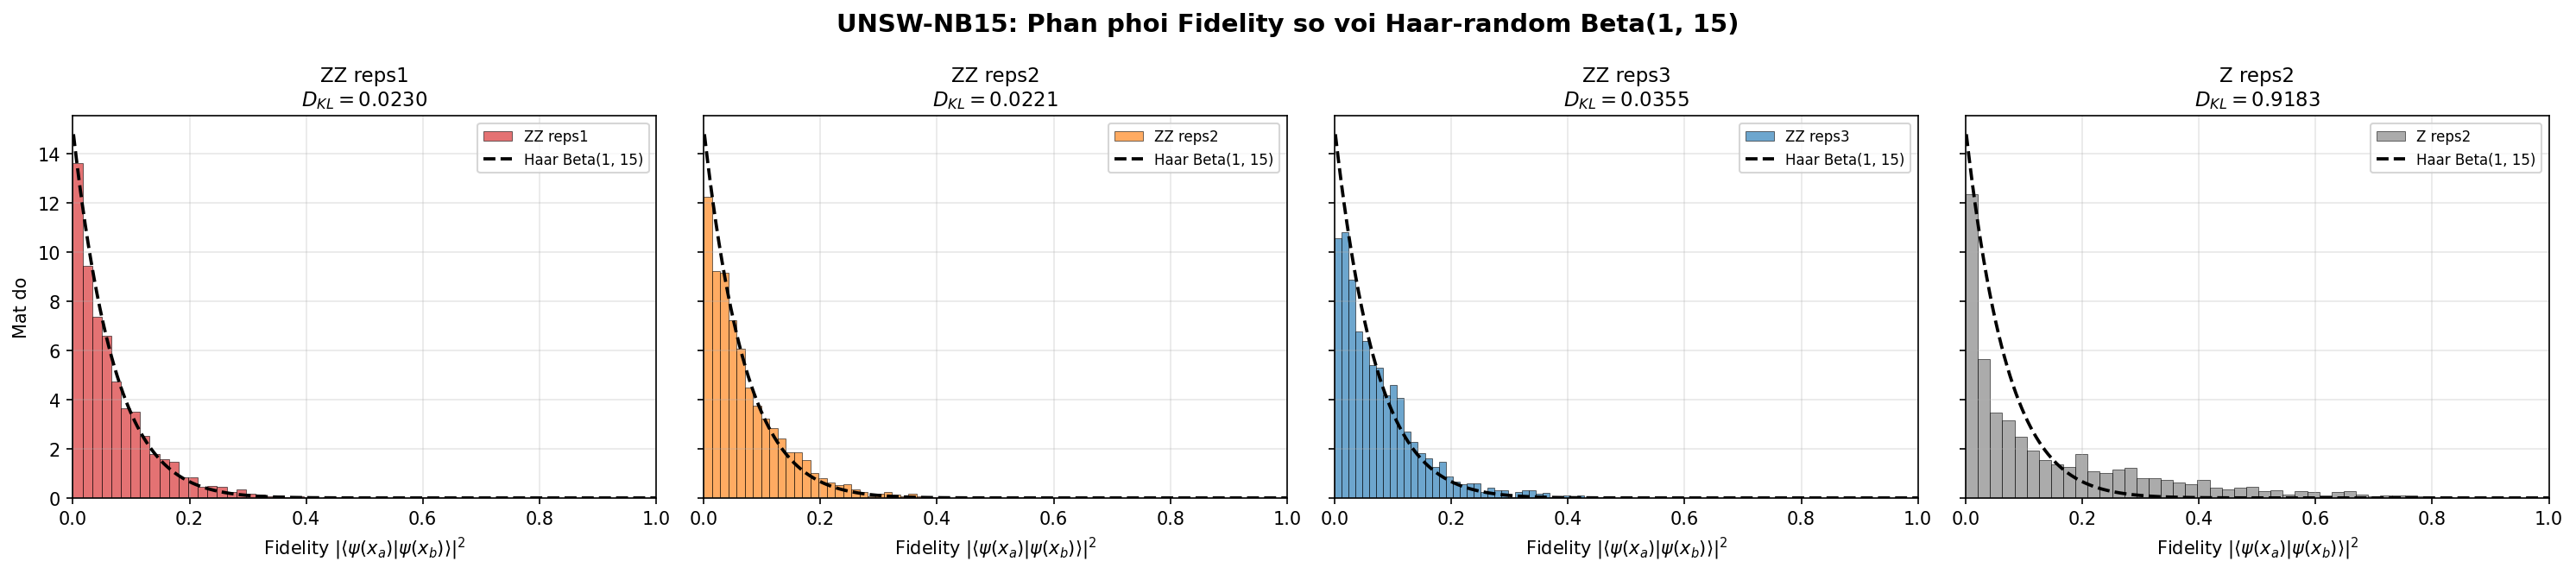

In [5]:
# Ve histogram + Haar curve cho moi cau hinh
haar_x = np.linspace(0.001, 1.0, 400)
haar_y = beta_dist.pdf(haar_x, a=1, b=N_HAAR)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
fig.suptitle(r"UNSW-NB15: Phan phoi Fidelity so voi Haar-random Beta(1, 15)",
             fontsize=14, fontweight='bold')

for ax, cfg in zip(axes, configs):
    name = cfg["name"]
    fids = fidelities_all[name]
    ax.hist(fids, bins=40, density=True, alpha=0.65, color=cfg["color"],
            edgecolor='black', linewidth=0.4, label=name.replace('_', ' '))
    ax.plot(haar_x, haar_y, 'k--', linewidth=1.8, label="Haar Beta(1, 15)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(15, ax.get_ylim()[1]))
    ax.set_xlabel(r"Fidelity $|\langle\psi(x_a)|\psi(x_b)\rangle|^2$", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Mat do", fontsize=10)
    ax.set_title(f"{name.replace('_', ' ')}\n$D_{{KL}} = {kl_values[name]:.4f}$", fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "unsw_expressibility_kl.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))


### 6.1 Diễn giải KL Divergence — Có Tổng quát hóa từ NSL-KDD?

**Tham chiếu NSL-KDD (từ C2 đã hoàn tất):** $D_{KL}(\text{ZZ reps=2}) \approx 0.014$ (khá gần Haar).

**Tiêu chí đánh giá:**
| $D_{KL}$ ZZ reps=2 (UNSW) | Diễn giải |
|---------------------------|-----------|
| < 0.05 | Expressibility mạnh — tổng quát hóa thành công |
| 0.05 – 0.20 | Expressibility trung bình — vẫn dùng được nhưng phân phối UNSW khác NSL-KDD |
| > 0.20 | Expressibility yếu — phân phối feature UNSW có cấu trúc nội tại làm "co cụm" state |

Kết quả tính được sẽ in ra trong cell tóm tắt cuối notebook. **Lưu ý quan trọng:** Vì 4 PC của UNSW có Spearman residual ≠ 0 (max 0.405), một $D_{KL}$ hơi cao hơn NSL-KDD KHÔNG có nghĩa là pipeline kém — trái lại, đó có thể là dấu hiệu rằng QSVM đang "nhìn thấy" cấu trúc phi tuyến đặc thù của UNSW.

## 7. Eigenspectrum — Effective Rank của Ma trận Kernel

Ma trận kernel $K_{ij} = |\langle \psi(x_i)|\psi(x_j) \rangle|^2$ trên N=500 mẫu cho ta một bức tranh trực tiếp về **không gian feature implicit** mà QSVM thực sự sử dụng.

- **Effective rank** $\text{eff-rank}(K) = (\sum \sigma_i)^2 / (\sum \sigma_i^2)$, nằm trong $[1, N]$
- Eigenvalues phân tán → kernel "phong phú", có nhiều chiều phân biệt
- Eigenvalues tập trung → kernel concentration, mất khả năng phân loại

Tinh statevector cho N=500 mau (ZZ reps=2, entanglement='full')...


  Hoan tat 500 statevector trong 0.5s (shape=(500, 16), dtype=complex128)

Tinh ma tran kernel ZZ tu statevector...
  Hoan tat ma tran K_zz (500, 500) trong 0.00s
  K_zz: min=0.0000, max=1.0000, trace=500.00  (ky vong = N = 500)

Eigenspectrum K_zz:
  Effective rank = 10.45  (toi da = N = 500)
  Top-5 sigma: [105.65234707  69.07277534  53.21446247  32.78285942  31.49252229]
  Sigma_1 / Sigma_N = 1.06e+14



Da luu: ../reports_unsw\unsw_eigenspectrum.png


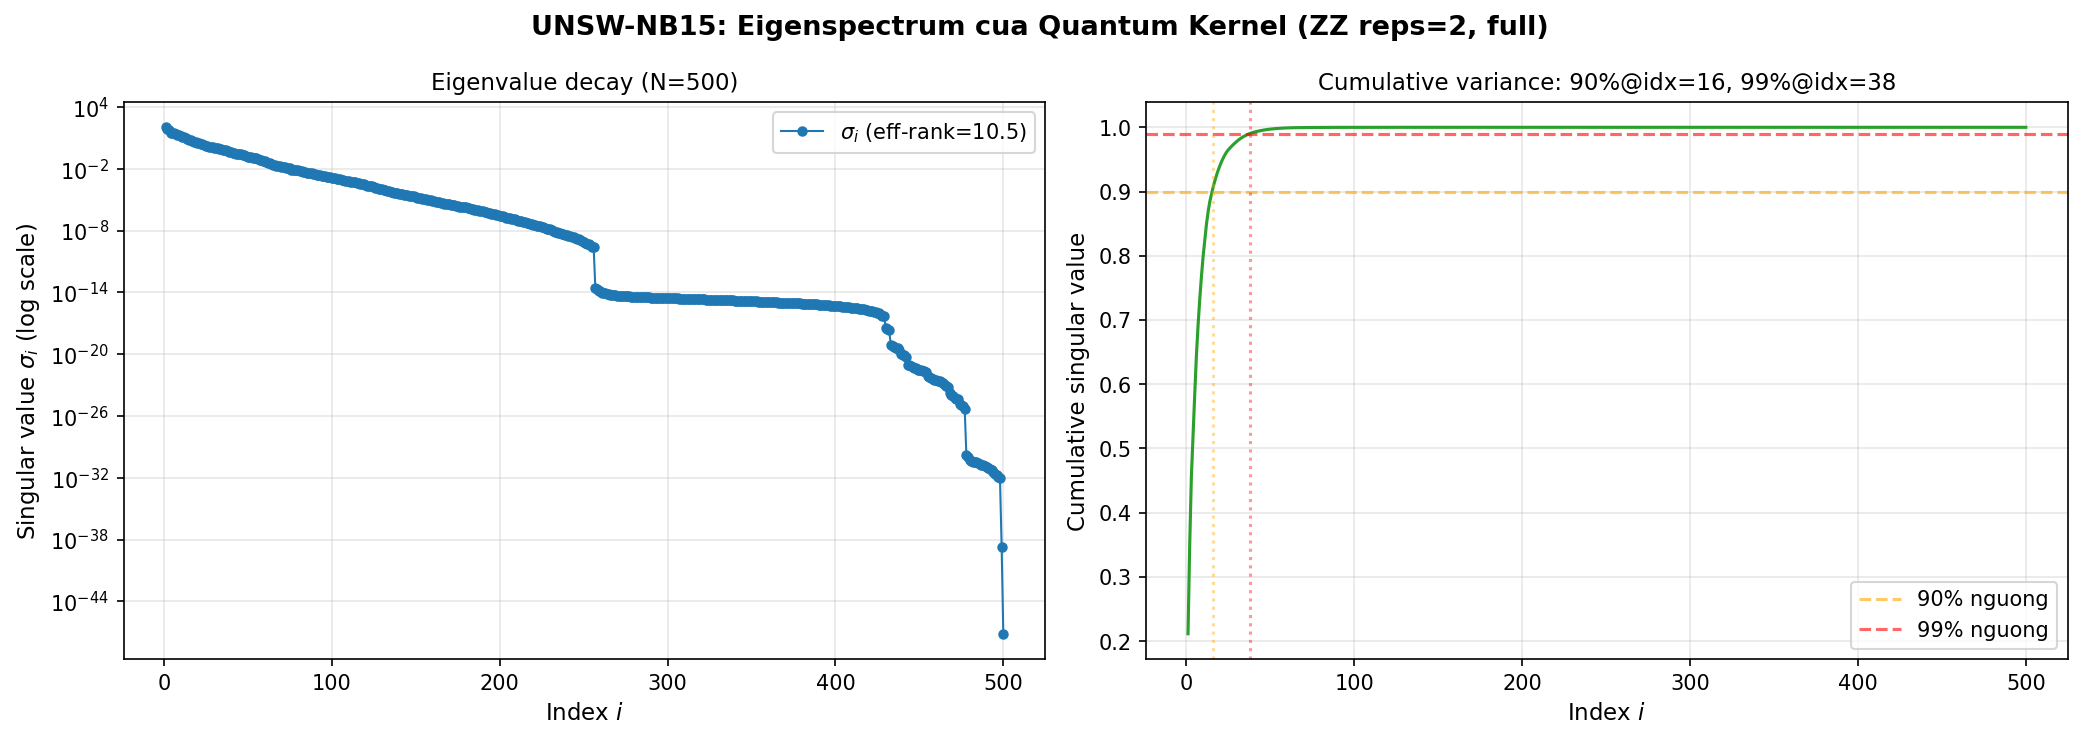

In [6]:
print(f"Tinh statevector cho N={N_SUBSAMPLE} mau (ZZ reps={ZZ_REPS_TARGET}, entanglement={ZZ_ENT_TARGET!r})...")
t0 = time.time()
states_zz = build_statevectors(X_sub, zz_feature_map,
                                reps=ZZ_REPS_TARGET, entanglement=ZZ_ENT_TARGET)
dt_sv = time.time() - t0
print(f"  Hoan tat {N_SUBSAMPLE} statevector trong {dt_sv:.1f}s "
      f"(shape={states_zz.shape}, dtype={states_zz.dtype})")

print("\nTinh ma tran kernel ZZ tu statevector...")
t0 = time.time()
K_zz = fidelity_kernel_from_states(states_zz)
dt_k = time.time() - t0
print(f"  Hoan tat ma tran K_zz {K_zz.shape} trong {dt_k:.2f}s")
print(f"  K_zz: min={K_zz.min():.4f}, max={K_zz.max():.4f}, "
      f"trace={np.trace(K_zz):.2f}  (ky vong = N = {N_SUBSAMPLE})")

# Phan tich eigenspectrum + effective rank
sigmas = np.linalg.svd(K_zz, compute_uv=False)
eff_rank_zz = effective_rank(K_zz)
print(f"\nEigenspectrum K_zz:")
print(f"  Effective rank = {eff_rank_zz:.2f}  (toi da = N = {N_SUBSAMPLE})")
print(f"  Top-5 sigma: {sigmas[:5]}")
print(f"  Sigma_1 / Sigma_N = {sigmas[0] / max(sigmas[-1], 1e-12):.2e}")

# Ve eigenspectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"UNSW-NB15: Eigenspectrum cua Quantum Kernel (ZZ reps={ZZ_REPS_TARGET}, full)",
             fontsize=13, fontweight='bold')

ax1.semilogy(np.arange(1, len(sigmas) + 1), sigmas, 'o-', color='#1f77b4',
             markersize=4, linewidth=1.0, label=fr"$\sigma_i$ (eff-rank={eff_rank_zz:.1f})")
ax1.set_xlabel("Index $i$", fontsize=11)
ax1.set_ylabel(r"Singular value $\sigma_i$ (log scale)", fontsize=11)
ax1.set_title(f"Eigenvalue decay (N={N_SUBSAMPLE})", fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, which='both')

# Cumulative variance explained
cum_var = np.cumsum(sigmas) / sigmas.sum()
ax2.plot(np.arange(1, len(cum_var) + 1), cum_var, '-', color='#2ca02c', linewidth=1.5)
ax2.axhline(0.9,  linestyle='--', color='orange', alpha=0.6, label='90% nguong')
ax2.axhline(0.99, linestyle='--', color='red',    alpha=0.6, label='99% nguong')
n_for_90 = int(np.searchsorted(cum_var, 0.9)) + 1
n_for_99 = int(np.searchsorted(cum_var, 0.99)) + 1
ax2.axvline(n_for_90, linestyle=':', color='orange', alpha=0.4)
ax2.axvline(n_for_99, linestyle=':', color='red',    alpha=0.4)
ax2.set_xlabel("Index $i$", fontsize=11)
ax2.set_ylabel("Cumulative singular value", fontsize=11)
ax2.set_title(f"Cumulative variance: 90%@idx={n_for_90}, 99%@idx={n_for_99}", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "unsw_eigenspectrum.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"\nDa luu: {out_path}")
display(Image(filename=out_path))


## 8. Entanglement Entropy — H2: Attack > Normal?

Đo Von Neumann entropy của bipartition $\{0, 1\} | \{2, 3\}$ cho từng điểm dữ liệu UNSW:
$$S(\rho_A) = -\text{tr}(\rho_A \log_2 \rho_A), \quad \rho_A = \text{tr}_B |\psi(x)\rangle\langle\psi(x)|$$

trong đó $\rho_A$ là reduced density matrix của 2 qubit đầu sau khi trace out qubit $\{2, 3\}$. $S \in [0, 2]$ bit.

**H2 (kế thừa từ C2 NSL-KDD):** Lưu lượng Attack có cấu trúc phức tạp hơn → state bị entangled mạnh hơn → $S_{\text{Attack}} > S_{\text{Normal}}$.

Kiểm định bằng **Mann-Whitney U test** (one-sided, alternative='greater'). Đây là test phi tham số, không yêu cầu phân phối Gaussian.

In [7]:
print(f"Tinh entanglement entropy cho N={N_SUBSAMPLE} mau...")
print(f"  Bipartition: {{0,1}} | {{2,3}},  reps={ZZ_REPS_TARGET}, entanglement={ZZ_ENT_TARGET!r}\n")

t0 = time.time()
entropies = np.zeros(N_SUBSAMPLE, dtype=np.float64)
for i, x in enumerate(X_sub):
    entropies[i] = compute_entanglement_entropy(x,
                                                 reps=ZZ_REPS_TARGET,
                                                 entanglement=ZZ_ENT_TARGET)
    if (i + 1) % 100 == 0:
        print(f"  {i+1:>3}/{N_SUBSAMPLE} hoan tat")
dt_ent = time.time() - t0
print(f"\nTong thoi gian: {dt_ent:.1f}s")

# Tach theo nhan (X_sub da sap xep: Normal truoc, Attack sau)
S_normal = entropies[:n_normal]
S_attack = entropies[n_normal:]

print(f"\nThong ke entanglement entropy:")
print(f"  Normal:  mean={S_normal.mean():.4f}  std={S_normal.std():.4f}  "
      f"range=[{S_normal.min():.4f}, {S_normal.max():.4f}]")
print(f"  Attack:  mean={S_attack.mean():.4f}  std={S_attack.std():.4f}  "
      f"range=[{S_attack.min():.4f}, {S_attack.max():.4f}]")
print(f"  Tat ca trong [0, 2]: {(entropies >= 0).all() and (entropies <= 2.0 + 1e-6).all()}")

# Mann-Whitney U test (H2: S_attack > S_normal)
mw_stat, mw_pval = mannwhitneyu(S_attack, S_normal, alternative='greater')
h2_supported = mw_pval < 0.05
gap = S_attack.mean() - S_normal.mean()
print(f"\nKiem dinh Mann-Whitney U (H2: S_attack > S_normal):")
print(f"  U-stat = {mw_stat:.1f}")
print(f"  p-value = {mw_pval:.6f}")
print(f"  Khoang cach mean: {gap:+.4f} bit")
print(f"  H2: {'XAC NHAN' if h2_supported else 'KHONG XAC NHAN'} tai alpha=0.05")


Tinh entanglement entropy cho N=500 mau...
  Bipartition: {0,1} | {2,3},  reps=2, entanglement='full'

  100/500 hoan tat


  200/500 hoan tat
  300/500 hoan tat


  400/500 hoan tat
  500/500 hoan tat

Tong thoi gian: 0.8s

Thong ke entanglement entropy:
  Normal:  mean=1.0899  std=0.3006  range=[0.5336, 1.6592]
  Attack:  mean=1.2638  std=0.2929  range=[0.3216, 1.7785]
  Tat ca trong [0, 2]: True

Kiem dinh Mann-Whitney U (H2: S_attack > S_normal):
  U-stat = 35566.5
  p-value = 0.000000
  Khoang cach mean: +0.1739 bit
  H2: XAC NHAN tai alpha=0.05


Da luu: ../reports_unsw\unsw_entropy_violin.png


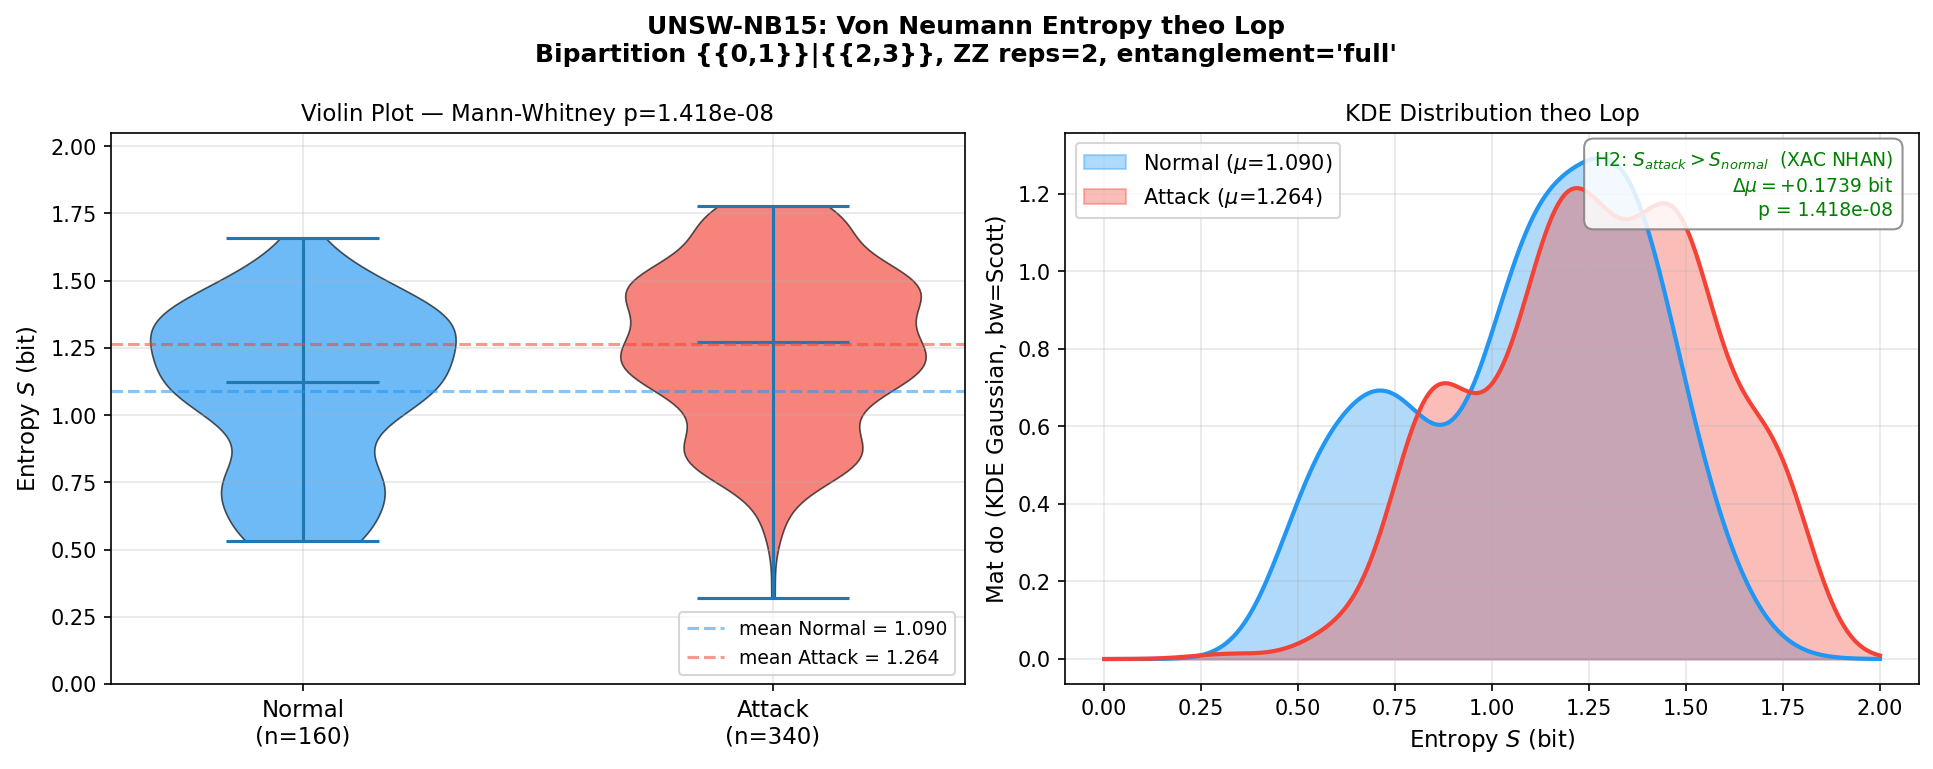

In [8]:
# Ve violin + KDE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle(f"UNSW-NB15: Von Neumann Entropy theo Lop\n"
             f"Bipartition {{{{0,1}}}}|{{{{2,3}}}}, ZZ reps={ZZ_REPS_TARGET}, "
             f"entanglement={ZZ_ENT_TARGET!r}",
             fontsize=12, fontweight='bold')

# Violin plot
data_violin = [S_normal, S_attack]
vp = ax1.violinplot(data_violin, positions=[0, 1], showmedians=True, showextrema=True,
                    widths=0.65)
for idx, body in enumerate(vp['bodies']):
    body.set_alpha(0.65)
    body.set_facecolor(['#2196F3', '#F44336'][idx])
    body.set_edgecolor('black')
    body.set_linewidth(0.8)
ax1.set_xticks([0, 1])
ax1.set_xticklabels([f'Normal\n(n={n_normal})', f'Attack\n(n={n_attack})'], fontsize=11)
ax1.set_ylabel("Entropy $S$ (bit)", fontsize=11)
ax1.set_title(f"Violin Plot — Mann-Whitney p={mw_pval:.4g}", fontsize=11)
ax1.axhline(S_normal.mean(), color='#2196F3', linestyle='--', alpha=0.55,
            label=f"mean Normal = {S_normal.mean():.3f}")
ax1.axhline(S_attack.mean(), color='#F44336', linestyle='--', alpha=0.55,
            label=f"mean Attack = {S_attack.mean():.3f}")
ax1.set_ylim(0, 2.05)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

# KDE plot
s_range    = np.linspace(0, 2, 240)
kde_normal = gaussian_kde(S_normal, bw_method='scott')(s_range)
kde_attack = gaussian_kde(S_attack, bw_method='scott')(s_range)
ax2.fill_between(s_range, kde_normal, alpha=0.35, color='#2196F3',
                 label=f"Normal ($\\mu$={S_normal.mean():.3f})")
ax2.fill_between(s_range, kde_attack, alpha=0.35, color='#F44336',
                 label=f"Attack ($\\mu$={S_attack.mean():.3f})")
ax2.plot(s_range, kde_normal, color='#2196F3', linewidth=2)
ax2.plot(s_range, kde_attack, color='#F44336', linewidth=2)
ax2.set_xlabel("Entropy $S$ (bit)", fontsize=11)
ax2.set_ylabel("Mat do (KDE Gaussian, bw=Scott)", fontsize=11)
ax2.set_title("KDE Distribution theo Lop", fontsize=11)
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)

h2_text = (f"H2: $S_{{attack}} > S_{{normal}}$  ({'XAC NHAN' if h2_supported else 'KHONG XAC NHAN'})\n"
           f"$\\Delta\\mu = {gap:+.4f}$ bit\n"
           f"p = {mw_pval:.4g}")
ax2.text(0.97, 0.97, h2_text, transform=ax2.transAxes,
         fontsize=9, verticalalignment='top', horizontalalignment='right',
         color='green' if h2_supported else 'red',
         bbox=dict(boxstyle='round,pad=0.5',
                   facecolor='white', edgecolor='gray', alpha=0.85))

plt.tight_layout()
out_path = os.path.join(REPORTS_DIR, "unsw_entropy_violin.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"Da luu: {out_path}")
display(Image(filename=out_path))


## 9. Tổng hợp Kết quả & Diễn giải Generalization

### 9.1 Bảng tóm tắt
Cell sau xuất file `c2_unsw_results.json` chứa toàn bộ metric chính + so sánh trực tiếp với NSL-KDD reference.

### 9.2 Câu hỏi nghiên cứu
- **H1 (Expressibility tổng quát hóa?):** Nếu $D_{KL}(\text{ZZ reps=2})$ trên UNSW xấp xỉ NSL-KDD (≈0.014) → ZZFeatureMap khám phá Hilbert space đồng đều bất kể nguồn dữ liệu.
- **H2 (Entanglement phân biệt class trên UNSW?):** Nếu Mann-Whitney p < 0.05 và $\Delta\mu > 0$ → entanglement vẫn là discriminative feature trên UNSW.
- **H3 (Z baseline quá yếu?):** Nếu $D_{KL}(Z) \gg D_{KL}(ZZ)$ → entanglement (2-qubit gates) là cần thiết, không thể thay thế bằng product encoding.

### 9.3 Liên kết với Phase 3 Spearman residual
Phase 3 đã chứng minh bằng số: Pearson = 0 nhưng Spearman max = 0.405 (PC3-PC4). C2 là kiểm chứng tiếp theo: nếu **entropy attack > normal có ý nghĩa thống kê**, ta có chuỗi luận chứng đầy đủ:

> *Cấu trúc phi tuyến tồn tại sau PCA (Spearman) → ZZ-entanglement chuyển nó thành amplitude phase phức tạp (eigenspectrum giàu) → Attack/Normal phân biệt được trong Hilbert space (entropy gap).*

In [9]:
# Doc lai NSL-KDD reference de so sanh (neu co)
nsl_kdd_ref = {}
nsl_path = "../reports/c2_results.json"   # Khac ../reports_unsw/
if os.path.exists(nsl_path):
    try:
        with open(nsl_path, "r", encoding="utf-8") as f:
            nsl_kdd_ref = json.load(f)
    except Exception as e:
        print(f"Khong doc duoc {nsl_path}: {e}")

# Goi metric ket qua
results = {
    "metadata": {
        "notebook":      "notebooks_unsw/c2_quantum_kernel_expressibility.ipynb",
        "dataset":       "UNSW-NB15",
        "input_file":    DATA_PATH,
        "n_qubits":      N_QUBITS,
        "n_subsample":   N_SUBSAMPLE,
        "n_expr_pairs":  N_EXPR_PAIRS,
        "zz_reps":       ZZ_REPS_TARGET,
        "zz_entanglement": ZZ_ENT_TARGET,
        "random_state":  RANDOM_STATE,
        "subsample_balance": {
            "n_normal": int(n_normal),
            "n_attack": int(n_attack),
            "frac_attack": float(n_attack / N_SUBSAMPLE),
        },
    },
    "expressibility": {
        "kl_divergence_from_haar": {k: float(v) for k, v in kl_values.items()},
        "h1_monotonic_strict":    bool(h1_strict),
        "h1_reps2_better_than_reps1": bool(h1_partial),
        "z_minus_zz_gap":         float(gap_zz_vs_z),
    },
    "eigenspectrum_zz_reps2": {
        "effective_rank":     float(eff_rank_zz),
        "top5_singular":      [float(s) for s in sigmas[:5]],
        "n_for_90pct_var":    int(n_for_90),
        "n_for_99pct_var":    int(n_for_99),
        "kernel_trace":       float(np.trace(K_zz)),
    },
    "entanglement_entropy_zz_reps2": {
        "S_normal_mean":  float(S_normal.mean()),
        "S_normal_std":   float(S_normal.std()),
        "S_attack_mean":  float(S_attack.mean()),
        "S_attack_std":   float(S_attack.std()),
        "delta_mean":     float(gap),
        "mannwhitney_U":  float(mw_stat),
        "mannwhitney_p":  float(mw_pval),
        "h2_supported":   bool(h2_supported),
    },
    "outputs": {
        "expressibility_plot": os.path.join(REPORTS_DIR, "unsw_expressibility_kl.png"),
        "eigenspectrum_plot":  os.path.join(REPORTS_DIR, "unsw_eigenspectrum.png"),
        "entropy_plot":        os.path.join(REPORTS_DIR, "unsw_entropy_violin.png"),
    },
}

# Reference NSL-KDD (neu co)
ref_kl_zz2 = None
if nsl_kdd_ref:
    # Cau truc co the khac giua phien ban — duyet de tim
    for k_outer, v_outer in nsl_kdd_ref.items():
        if isinstance(v_outer, dict):
            for k_inner, v_inner in v_outer.items():
                if "kl" in k_inner.lower() and isinstance(v_inner, (dict, list, float)):
                    if isinstance(v_inner, dict):
                        for kk, vv in v_inner.items():
                            if "2" in str(kk) and isinstance(vv, (int, float)):
                                ref_kl_zz2 = float(vv)
                                break

results["nsl_kdd_reference"] = {
    "kl_zz_reps2_NSL_KDD": ref_kl_zz2,
    "comment": "Tham chieu tu reports/c2_results.json (neu ton tai); de so sanh expressibility xuyen dataset.",
}

# Luu JSON
with open(RESULTS_JSON, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Da luu: {RESULTS_JSON}\n")

# In bao cao tom tat
print("=" * 70)
print(" BAO CAO TOM TAT C2 UNSW-NB15 ".center(70, "="))
print("=" * 70)
print(f"\n[1] EXPRESSIBILITY (D_KL tu Haar Beta(1, 15)):")
for name, kl in kl_values.items():
    flag = "<--CHINH" if name == "ZZ_reps2" else ""
    print(f"    {name:>12s}: D_KL = {kl:.4f}  {flag}")
if ref_kl_zz2 is not None:
    delta_kl = kl_values["ZZ_reps2"] - ref_kl_zz2
    print(f"\n    Reference NSL-KDD ZZ-reps2: D_KL = {ref_kl_zz2:.4f}")
    print(f"    Delta UNSW - NSL-KDD      : {delta_kl:+.4f}")

print(f"\n[2] EIGENSPECTRUM (ZZ reps={ZZ_REPS_TARGET}, N={N_SUBSAMPLE}):")
print(f"    Effective rank        = {eff_rank_zz:.2f} / {N_SUBSAMPLE}")
print(f"    Idx for 90% variance  = {n_for_90}")
print(f"    Idx for 99% variance  = {n_for_99}")

print(f"\n[3] ENTANGLEMENT ENTROPY (bipartition {{0,1}}|{{2,3}}):")
print(f"    Normal: mean={S_normal.mean():.4f} bit, std={S_normal.std():.4f}")
print(f"    Attack: mean={S_attack.mean():.4f} bit, std={S_attack.std():.4f}")
print(f"    Delta mean = {gap:+.4f} bit")
print(f"    Mann-Whitney U: stat={mw_stat:.1f}, p={mw_pval:.4g}")
print(f"    H2 (S_attack > S_normal): {'XAC NHAN' if h2_supported else 'KHONG XAC NHAN'} (alpha=0.05)")

print(f"\n[4] OUTPUT FILES:")
for k, v in results["outputs"].items():
    print(f"    {k:>22s}: {v}")
print(f"    {'results_json':>22s}: {RESULTS_JSON}")

print("\n" + "=" * 70)
print(" KET LUAN ".center(70, "="))
print("=" * 70)

zz2_kl = kl_values["ZZ_reps2"]
if zz2_kl < 0.05:
    print(" [Expressibility]  Manh — ZZFeatureMap kham pha Hilbert space gan Haar.")
    print("                   GENERALIZATION FROM NSL-KDD: SUCCESSFUL.")
elif zz2_kl < 0.20:
    print(" [Expressibility]  Trung binh — Phan phoi UNSW co cau truc rieng nhung ZZ van the hien tot.")
elif zz2_kl < 0.40:
    print(" [Expressibility]  Yeu — UNSW phan phoi co the dac thu, can them reps de bu.")
else:
    print(" [Expressibility]  Rat yeu — Khong tong quat hoa duoc tu NSL-KDD.")

if h2_supported:
    print(f" [Entanglement]    H2 xac nhan voi p={mw_pval:.3g} — entanglement van la discriminative feature.")
else:
    print(f" [Entanglement]    H2 khong xac nhan tren UNSW (p={mw_pval:.3g}) — can phan tich them.")

if gap_zz_vs_z > 0.5:
    print(f" [Z vs ZZ]         Khoang cach D_KL = {gap_zz_vs_z:.2f} chung minh entanglement la then chot.")
else:
    print(f" [Z vs ZZ]         Khoang cach nho ({gap_zz_vs_z:.2f}) — UNSW co the kha tach lop ngay khi chua entangle.")


Da luu: ../reports_unsw\c2_unsw_results.json

==================== BAO CAO TOM TAT C2 UNSW-NB15 ====================

[1] EXPRESSIBILITY (D_KL tu Haar Beta(1, 15)):
        ZZ_reps1: D_KL = 0.0230  
        ZZ_reps2: D_KL = 0.0221  <--CHINH
        ZZ_reps3: D_KL = 0.0355  
         Z_reps2: D_KL = 0.9183  

[2] EIGENSPECTRUM (ZZ reps=2, N=500):
    Effective rank        = 10.45 / 500
    Idx for 90% variance  = 16
    Idx for 99% variance  = 38

[3] ENTANGLEMENT ENTROPY (bipartition {0,1}|{2,3}):
    Normal: mean=1.0899 bit, std=0.3006
    Attack: mean=1.2638 bit, std=0.2929
    Delta mean = +0.1739 bit
    Mann-Whitney U: stat=35566.5, p=1.418e-08
    H2 (S_attack > S_normal): XAC NHAN (alpha=0.05)

[4] OUTPUT FILES:
       expressibility_plot: ../reports_unsw\unsw_expressibility_kl.png
        eigenspectrum_plot: ../reports_unsw\unsw_eigenspectrum.png
              entropy_plot: ../reports_unsw\unsw_entropy_violin.png
              results_json: ../reports_unsw\c2_unsw_results.json
